## Lending Club(금융 대출) 데이터를 활용한 SQL 분석

In [2]:
import duckdb

duckdb.sql("SELECT version()").show()


┌─────────────┐
│ "version"() │
│   varchar   │
├─────────────┤
│ v1.5.5      │
└─────────────┘



In [3]:
%load_ext sql
%sql duckdb:///:memory:

Connecting to 'duckdb:///:memory:'

In [4]:
duckdb.sql("DESCRIBE SELECT * FROM 'data/accepted_2007_to_2018Q4.csv'").show()

┌────────────────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│          column_name           │ column_type │  null   │   key   │ default │  extra  │
│            varchar             │   varchar   │ varchar │ varchar │ varchar │ varchar │
├────────────────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ id                             │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ member_id                      │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ loan_amnt                      │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ funded_amnt                    │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ funded_amnt_inv                │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ term                           │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ int_rate                       │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ installment        

In [5]:
%%sql
-- 뷰 만들기 (테이블 별칭 지정)
CREATE VIEW loan AS
SELECT * FROM 'data/accepted_2007_to_2018Q4.csv';

Running query in 'duckdb:///:memory:'

Count


In [6]:
%%sql
SELECT loan_amnt, funded_amnt, term, int_rate, grade, sub_grade,
emp_length, home_ownership, annual_inc, issue_d, loan_status, purpose, dti
FROM loan
LIMIT 10;

Running query in 'duckdb:///:memory:'

loan_amnt,funded_amnt,term,int_rate,grade,sub_grade,emp_length,home_ownership,annual_inc,issue_d,loan_status,purpose,dti
3600.0,3600.0,36 months,13.99,C,C4,10+ years,MORTGAGE,55000.0,Dec-2015,Fully Paid,debt_consolidation,5.91
24700.0,24700.0,36 months,11.99,C,C1,10+ years,MORTGAGE,65000.0,Dec-2015,Fully Paid,small_business,16.06
20000.0,20000.0,60 months,10.78,B,B4,10+ years,MORTGAGE,63000.0,Dec-2015,Fully Paid,home_improvement,10.78
35000.0,35000.0,60 months,14.85,C,C5,10+ years,MORTGAGE,110000.0,Dec-2015,Current,debt_consolidation,17.06
10400.0,10400.0,60 months,22.45,F,F1,3 years,MORTGAGE,104433.0,Dec-2015,Fully Paid,major_purchase,25.37
11950.0,11950.0,36 months,13.44,C,C3,4 years,RENT,34000.0,Dec-2015,Fully Paid,debt_consolidation,10.2
20000.0,20000.0,36 months,9.17,B,B2,10+ years,MORTGAGE,180000.0,Dec-2015,Fully Paid,debt_consolidation,14.67
20000.0,20000.0,36 months,8.49,B,B1,10+ years,MORTGAGE,85000.0,Dec-2015,Fully Paid,major_purchase,17.61
10000.0,10000.0,36 months,6.49,A,A2,6 years,RENT,85000.0,Dec-2015,Fully Paid,credit_card,13.07
8000.0,8000.0,36 months,11.48,B,B5,10+ years,MORTGAGE,42000.0,Dec-2015,Fully Paid,credit_card,34.8


**주요컬럼**
- loan_amnt: 신청자가 요청한 대출 금액
- funded_amnt: 투자자들이 조달해준 대출 금액 (주로 loan_amnt와 동일)
- term: 대출 만기 기간 (36개월 또는 60개월)
- int_rate: 이자율(%)
- grade: 신용등급 (A, B, C, D, E, F, G)
- sub_grade: 대출 등급 세분화 (A1/A2, B1/B2, C1/C2, D1/D2, E1/E2, F1/F2, G1/G2) 
- emp_length: 근속년수 (10+ years, 9 years, 8 years, ... 0 years)
- home_ownership: 주택 소유 형태 (RENT=임차, OWN=자가, MORTGAGE=대출로 보유, OTHER)
- annual_inc: 연 소득
- issue_d: 대출 발행일 (YYYY-MM-DD)
- loan_status: 대출 상태 (Fully Paid=완납, Charged Off=회수불능/부실 등, 
                        Current=상환 중, Issued, In Grace Period=유예기간, 
                        Late (16-30 days), Late (31-120 days), 
                        Default-연체 121 이상 지속되어 채무불이행 상태로 전환됨)
- purpose: 대출 목적 (credit_card=카드빚 상환, debt_consolidation=부채 통합, home_improvement=주택 개선, 
                    major_purchase=할부가 필요한 고액 상품 구매, small_business=소규모 사업, 
                    vacation, wedding, other)
- dti: 부채 상환 비율 (debt to income ratio, 소득 대비 부채 비율(%) - 높을수록 부채 부담이 큼)

**위 데이터로 파악할 수 있는 것들**
- grade(신용등급)이 낮을수록 int_rate(이자율)이 높아짐 -> 신용등급이 이자율을 결정하는 핵심 요인임을 알 수 있음
- 위 데이터(limit 10)로만 봤을 때 loan_status(대출상태)가 하나를 제외하고 'Fully Paid' -> DISTINCT로 확인 필

In [7]:
%%sql
SELECT DISTINCT loan_status
FROM loan;

Running query in 'duckdb:///:memory:'

loan_status
Late (16-30 days)
Does not meet the credit policy. Status:Charged Off
Current
Default
None
Does not meet the credit policy. Status:Fully Paid
Charged Off
In Grace Period
Fully Paid
Late (31-120 days)


In [8]:
%%sql
SELECT loan_status, COUNT(*) AS cnt -- 대출상태, 대출상태 개수(cnt)
FROM loan
GROUP BY loan_status
ORDER BY cnt DESC;

Running query in 'duckdb:///:memory:'

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

loan_status,cnt
Fully Paid,1076751
Current,878317
Charged Off,268559
Late (31-120 days),21467
In Grace Period,8436
Late (16-30 days),4349
Does not meet the credit policy. Status:Fully Paid,1988
Does not meet the credit policy. Status:Charged Off,761
Default,40
None,33


### 총 대출 건수 대비 부실률 파악

In [9]:
%%sql
-- loan_status 중 부실(Charged Off-회수불능, Default-연체 121 이상 지속되어 채무불이행 상태로 전환됨) 상태의 비율 확인 (부실률)
-- 부실률을 계산할 때는 유예, late 상태는 제외하고 확실한 부실 상태만 고려
-- 부실률 = 부실건수 / 전체건수 * 100
-- CASE WHEN = python IF => CASE WHEN 조건 THEN 1 ELSE 0 END
-- CAST(값) AS DOUBLE = 값을 float 형태로 변환 => DOUBLE로 변환해야 정확한 소수(비율) 출력 가능
SELECT
    CAST(SUM(CASE WHEN loan_status IN ('Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off') 
             THEN 1 ELSE 0 END) AS DOUBLE)
    / COUNT(*) * 100 AS bad_rate
FROM loan;

Running query in 'duckdb:///:memory:'

bad_rate
11.914888346579225


전체 대출 건 중 11.91%가 부실로 종결됨.

### 신용등급별 부실률 파악

In [10]:
%%sql
-- 신용등급별 부실률도 확인해보기
-- 신용등급별 대출 건수도 같이 확인 (total_cnt)
SELECT 
    grade,
    CAST(SUM(CASE WHEN loan_status IN ('Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off')
            THEN 1 ELSE 0 END) AS DOUBLE)
    / COUNT(*) * 100 AS bad_rate,
    COUNT(*) AS total_cnt
FROM loan
GROUP BY grade
ORDER BY grade;

Running query in 'duckdb:///:memory:'

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

grade,bad_rate,total_cnt
A,3.282474302988035,433027
B,7.9361682568340015,663557
C,13.199692948113462,650053
D,18.88392967228072,324424
E,26.68775204771489,135639
F,34.89234449760766,41800
G,38.06706114398422,12168
None,0.0,33


In [11]:
%%sql
-- grade가 None인 부분 살펴보기
SELECT loan_status, issue_d
FROM loan
WHERE grade IS NULL;

Running query in 'duckdb:///:memory:'

loan_status,issue_d
None,None
None,None
None,None
None,None
None,None
None,None
None,None
None,None
None,None
None,None


결측치들 제거한 뷰 만들기 (원본 파일 자체를 수정하는 것이 x, 걸러낸 뷰를 만드는 방식)

In [12]:
%%sql
-- grade가 비어 있지 않은 행들만 loan_clean이라는 이름의 뷰에 추가
-- OR REPLACE : 같은 이름의 뷰가 이미 있을 시 여기에 덮어씌우기
CREATE OR REPLACE VIEW loan_clean AS
SELECT * 
FROM loan
WHERE grade IS NOT NULL;


Running query in 'duckdb:///:memory:'

Count


In [ ]:
%%sql
-- 대출발행일(issue_d)을 기준으로 쿼리 정리하기
-- 현재: "Dec-2015"< 문자열 형태
-- 정리 후: 날짜 형태 (STRPTIME 사용)

SELECT issue_d, 
    STRPTIME(issue_d, '%b-%Y') AS issue_date
FROM loan_clean
LIMIT 5;


Running query in 'duckdb:///:memory:'

issue_d,issue_date
Dec-2015,2015-12-01 00:00:00
Dec-2015,2015-12-01 00:00:00
Dec-2015,2015-12-01 00:00:00
Dec-2015,2015-12-01 00:00:00
Dec-2015,2015-12-01 00:00:00


In [14]:
%%sql
-- 원본 데이터에 년-월까지밖에 없으므로 일, 시간은 필요 없음
-- 일, 시간 잘라내고 월까지만 남기기
-- DATE_TRUNC(단위, 적용할 컬럼) : 2000-00-00 00:00:00 형태에서 단위만 표시됨
-- CAST() AS DATE: 날짜만 남기기 (0000-00-00 형태)
SELECT 
    CAST(DATE_TRUNC('month', STRPTIME(issue_d, '%b-%Y')) AS DATE) AS issue_month,
    COUNT(*) AS count_issue
FROM loan_clean
GROUP BY issue_month
ORDER BY issue_month;


Running query in 'duckdb:///:memory:'

issue_month,count_issue
2007-06-01,24
2007-07-01,63
2007-08-01,74
2007-09-01,53
2007-10-01,105
2007-11-01,112
2007-12-01,172
2008-01-01,305
2008-02-01,306
2008-03-01,402


In [15]:
%%sql
-- 코호트별 부실률까지 같이 확인하기
SELECT 
    grade,
    CAST(SUM(CASE WHEN loan_status IN ('Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off')
            THEN 1 ELSE 0 END) AS DOUBLE) / COUNT(*) * 100 AS bad_rate,
    CAST(DATE_TRUNC('month', STRPTIME(issue_d, '%b-%Y')) AS DATE) AS issue_month,
    COUNT(*) AS count_issue
FROM loan_clean
GROUP BY issue_month, grade
ORDER BY grade, issue_month;

Running query in 'duckdb:///:memory:'

grade,bad_rate,issue_month,count_issue
A,14.285714285714285,2007-06-01,7
A,0.0,2007-07-01,15
A,5.555555555555555,2007-08-01,18
A,0.0,2007-09-01,7
A,0.0,2007-10-01,8
A,0.0,2007-11-01,11
A,16.666666666666664,2007-12-01,12
A,11.11111111111111,2008-01-01,45
A,0.0,2008-02-01,30
A,8.571428571428571,2008-03-01,35


### 신용등급별 부실률이 대출 실행 시기에 따라 어떻게 다른지 확인

In [16]:
# 시각화로 신용등급별 부실률이 날짜에 따라 어떻게 다른지 한눈에 파악하기
result = %sql SELECT grade, \
    CAST(SUM(CASE WHEN loan_status IN ('Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off') \
            THEN 1 ELSE 0 END) AS DOUBLE) / COUNT(*) * 100 AS bad_rate, \
    CAST(DATE_TRUNC('month', STRPTIME(issue_d, '%b-%Y')) AS DATE) AS issue_month, \
    COUNT(*) AS count_issue \
    FROM loan_clean \
    GROUP BY issue_month, grade \
    ORDER BY grade, issue_month 

df = result.DataFrame()
df.head()

Running query in 'duckdb:///:memory:'

,grade,bad_rate,issue_month,count_issue
0,A,14.285714,2007-06-01,7
1,A,0.000000,2007-07-01,15
2,A,5.555556,2007-08-01,18
3,A,0.000000,2007-09-01,7
4,A,0.000000,2007-10-01,8


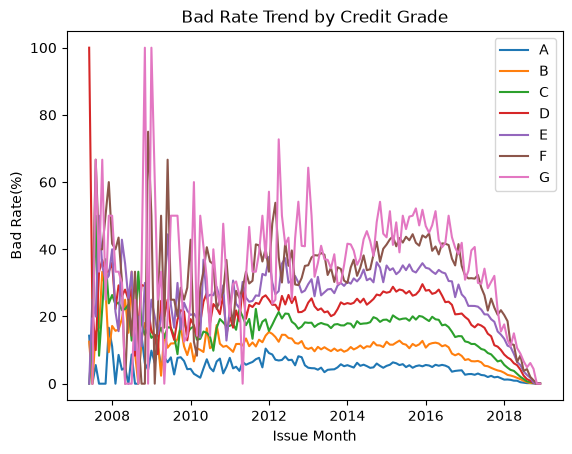

In [17]:
# matplotlib 활용한 신용등급에 따른 부실률 추이 시각화 진행
import matplotlib.pyplot as plt

for g in df['grade'].unique():
    subset = df[df['grade'] == g]
    plt.plot(subset['issue_month'], subset['bad_rate'], label=g)

plt.legend()
plt.xlabel('Issue Month')
plt.ylabel('Bad Rate(%)')
plt.title('Bad Rate Trend by Credit Grade')
plt.show()

1. 부실률 수준: 높은 등급(A,B,C,D)일수록 낮은 추이를 보임. 반면 G등급은 20~50%를 오가는 높은 부실률을 보임.
2. 불안정성: 신용등급이 낮을수록 부실률 추이 역시 쉽게 안정되지 않는 양상을 보임. 

### 퍼널 분석: 연체 단계별 전환율, 이탈율 분석

In [ ]:
%%sql
-- 연체 흐름을 단계로 파악해서 분석하기 (current-상환 중, Fully Paid-다 갚음:분석 대상에서 제외, 현재 연체 관련 상태만 추적)
-- 유예(grace) -> 16~30일 연체 -> ~120 연체 -> default(121일 이상 연체) -> charged off(회수불능)
-- 대출 상태(loan_status)별 상태를 단계 번호로 매핑하기
SELECT
    COUNT(*) AS status_cnt,
    (CASE 
        WHEN loan_status = 'In Grace Period' THEN 1
        WHEN loan_status = 'Late (16-30 days)' THEN 2
        WHEN loan_status = 'Late (31-120 days)' THEN 3
        WHEN loan_status = 'Default' THEN 4
        WHEN loan_status = 'Charged Off' OR 
             loan_status = 'Does not meet the credit policy. Status:Charged Off' THEN 5
        END) AS status_num
FROM loan_clean
WHERE loan_status IN ('In Grace Period', 'Late (16-30 days)', 'Late (31-120 days)', 
                    'Default', 'Charged Off', 'Does not meet the credit policy. Status:Charged Off')
GROUP BY status_num
ORDER BY status_num;

Running query in 'duckdb:///:memory:'

status_cnt,status_num
8436,1
4349,2
21467,3
40,4
269320,5


In [ ]:
%%sql
-- 신용등급별 월별 부실률을 기반으로, 이번달(issue_month) 안에서 부실률이 높은 순서대로 등급의 순위를 매겨보기
SELECT
    grade,
    CAST(SUM(CASE WHEN loan_status IN ('Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off')
            THEN 1 ELSE 0 END) AS DOUBLE) / COUNT(*) * 100 AS bad_rate,
    CAST(DATE_TRUNC('month', STRPTIME(issue_d, '%b-%Y')) AS DATE) AS issue_month,
    RANK() OVER(PARTITION BY issue_month ORDER BY bad_rate DESC) AS bad_rate_rank
FROM loan_clean
WHERE issue_month >= '2011-01-01'
GROUP BY issue_month, grade
ORDER BY grade, issue_month;

Running query in 'duckdb:///:memory:'

grade,bad_rate,issue_month,bad_rate_rank
A,7.6923076923076925,2011-01-01,7
A,4.5584045584045585,2011-02-01,7
A,5.056179775280898,2011-03-01,7
A,3.804347826086957,2011-04-01,7
A,6.467661691542288,2011-05-01,6
A,5.6367432150313155,2011-06-01,7
A,6.073752711496746,2011-07-01,7
A,6.469500924214418,2011-08-01,7
A,7.286821705426356,2011-09-01,7
A,7.703281027104136,2011-10-01,7


### RFM 분석 - 신용등급별 패턴 분석

- Recency: 등급별 가장 최근 대출 실행일 파악
- Frequency: 등급별 총 대출 건수
- Monetary: 등급별 평균(또는 총) 대출 금액

In [31]:
%%sql
SELECT
    grade,
    MAX(STRPTIME(issue_d, '%b-%Y')) AS recent_date,
    COUNT(*) AS total_cnt,
    AVG(loan_amnt) AS avg_amnt
FROM loan_clean
GROUP BY grade
ORDER BY grade;

Running query in 'duckdb:///:memory:'

grade,recent_date,total_cnt,avg_amnt
A,2018-12-01 00:00:00,433027,14603.343209545825
B,2018-12-01 00:00:00,663557,14173.33819852703
C,2018-12-01 00:00:00,650053,15038.083317821778
D,2018-12-01 00:00:00,324424,15711.98300680591
E,2018-12-01 00:00:00,135639,17453.078391907933
F,2018-12-01 00:00:00,41800,19124.64653110048
G,2018-12-01 00:00:00,12168,20383.988740959896
